# OpenProblems classification and batch-correction results

The two reviewer-requested behaviors are controlled independently in the
configuration cell below:

- `USE_ZSCORE`: standardize each dataset across methods before plotting.
- `EXCLUDE_MISSING_SCORES`: omit unavailable scores instead of treating them as zero.

`immune_cell_atlas` and `tabula_sapiens` are always excluded from every analysis and plot.

Plots are embedded in this notebook and exported to `plot_results_outputs/`.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Reviewer-requested options. They are independent and can be toggled separately.
USE_ZSCORE = True
EXCLUDE_MISSING_SCORES = True
PLOT_STYLE = "dots"
USE_ZSCORE = os.environ.get("PLOT_USE_ZSCORE", str(USE_ZSCORE)).lower() == "true"
EXCLUDE_MISSING_SCORES = (
    os.environ.get(
        "PLOT_EXCLUDE_MISSING_SCORES",
        str(EXCLUDE_MISSING_SCORES),
    ).lower()
    == "true"
)
EXCLUDED_DATASETS = {"immune_cell_atlas", "tabula_sapiens"}
CLASSIFICATION_DATASET_LABELS = {
    "dkd": "dkd (cell types: 13)",
    "gtex_v9": "gtex_v9 (cell types: 53)",
    "hypomap": "hypomap (cell types: 13)",
    "mouse_pancreas_atlas": "mouse_pancreas_atlas (cell types: 11)",
}
BATCH_DATASET_LABELS = {
    "dkd": "dkd (11 donors, 2 assays)",
    "gtex_v9": "gtex_v9 (16 donors, 1 assay)",
    "hypomap": "hypomap (24 donors, 4 assays)",
    "mouse_pancreas_atlas": (
        "mouse_pancreas_atlas (56 donors, 2 assays)"
    ),
}

SCORE_SCALE = "zscore" if USE_ZSCORE else "raw"
MISSING_POLICY = "nan_excluded" if EXCLUDE_MISSING_SCORES else "nan_as_zero"
VARIANT_NAME = f"{SCORE_SCALE}_{MISSING_POLICY}"
OUTPUT_DIR = Path("plot_results_outputs") / VARIANT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{USE_ZSCORE=}")
print(f"{EXCLUDE_MISSING_SCORES=}")
print(f"{EXCLUDED_DATASETS=}")
print(f"{VARIANT_NAME=}")
print(f"Plots will be written to: {OUTPUT_DIR.resolve()}")

USE_ZSCORE=True
EXCLUDE_MISSING_SCORES=True
EXCLUDED_DATASETS={'immune_cell_atlas', 'tabula_sapiens'}
VARIANT_NAME='zscore_nan_excluded'
Plots will be written to: /Users/jkobject/Documents/scPRINT/figures/plot_results_outputs/zscore_nan_excluded


In [2]:
data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

result_sources = {
    "results_batch.json": (
        "https://raw.githubusercontent.com/openproblems-bio/website/main/"
        "results/batch_integration/data/results.json"
    ),
    "results_label.json": (
        "https://raw.githubusercontent.com/openproblems-bio/website/main/"
        "results/label_projection/data/results.json"
    ),
}

for filename, url in result_sources.items():
    destination = data_dir / filename
    if not destination.exists():
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        destination.write_text(response.text)
    print(f"Using {destination}")

Using ../data/results_batch.json
Using ../data/results_label.json


In [3]:
def load_results(path):
    with path.open() as handle:
        records = json.load(handle)

    results = {}
    for record in records:
        dataset_id = record["dataset_id"]
        if (
            dataset_id is None
            or dataset_id.split("/")[-1] in EXCLUDED_DATASETS
        ):
            continue
        results.setdefault(dataset_id, {})[record["method_id"]] = record[
            "metric_values"
        ]
    return results


batch_results = load_results(data_dir / "results_batch.json")
classification_results = load_results(data_dir / "results_label.json")

print(
    f"Loaded {len(classification_results)} classification datasets and "
    f"{len(batch_results)} batch-correction datasets."
)

Loaded 4 classification datasets and 4 batch-correction datasets.


In [4]:
classification_results.keys()

dict_keys(['cellxgene_census/dkd', 'cellxgene_census/gtex_v9', 'cellxgene_census/hypomap', 'cellxgene_census/mouse_pancreas_atlas'])

In [5]:
def prepare_score_table(raw_scores):
    """Apply the two plotting policies without mutating the raw score table."""
    scores = raw_scores.apply(pd.to_numeric, errors="coerce").copy()

    if not EXCLUDE_MISSING_SCORES:
        scores = scores.fillna(0)

    if USE_ZSCORE:
        means = scores.mean(axis=0, skipna=True)
        standard_deviations = scores.std(axis=0, skipna=True, ddof=0)
        scores = scores.subtract(means, axis="columns")

        variable_columns = standard_deviations[standard_deviations > 0].index
        scores.loc[:, variable_columns] = scores.loc[:, variable_columns].divide(
            standard_deviations.loc[variable_columns], axis="columns"
        )

        # A constant dataset contains no ranking information. Keep its available
        # observations at the neutral z-score rather than manufacturing infinities.
        constant_columns = standard_deviations[standard_deviations == 0].index
        scores.loc[:, constant_columns] = scores.loc[:, constant_columns].where(
            scores.loc[:, constant_columns].isna(), 0.0
        )

    return scores


def plot_score_distribution(
    raw_scores,
    score_name,
    title,
    filename,
    dataset_labels=None,
    show_model_separators=False,
    separate_before_methods=None,
    figure_size=None,
):
    dataset_labels = dataset_labels or {}
    scores = prepare_score_table(raw_scores)
    plot_data = (
        scores.rename_axis("Method")
        .reset_index()
        .melt(id_vars="Method", var_name="Dataset", value_name="Score")
        .dropna(subset=["Score"])
    )

    method_order = [method for method in scores.index if method in plot_data["Method"].unique()]
    scores = scores.reindex(method_order)
    ranks = scores.rank(axis="index", ascending=False, method="min")
    mean_scores = scores.mean(axis="columns", skipna=True)
    mean_ranks = ranks.mean(axis="columns", skipna=True)

    if separate_before_methods is None:
        separate_before_methods = {
            "random_labels",
            "scgpt_zeroshot",
            "scPRINT-1 (zero-shot)",
        }

    if PLOT_STYLE == "dots":
        # Dot-only version of the original box/whisker plot. Dataset values
        # remain visible individually; the aggregate is the black diamond.
        method_positions = np.arange(len(method_order), dtype=float)

        dataset_order = list(scores.columns)
        point_offsets = np.linspace(-0.12, 0.12, len(dataset_order))
        # Preserve the categorical dataset colors from the original plots:
        # blue, orange, green, and red in dataset order.
        dataset_colors = sns.color_palette("deep", len(dataset_order))
        if figure_size is None:
            figure_size = (14, 10)
        fig, ax = plt.subplots(figsize=figure_size)
        fig.patch.set_facecolor("white")
        ax.set_facecolor("white")

        for dataset_index, dataset in enumerate(dataset_order):
            values = scores[dataset].reindex(method_order).to_numpy(dtype=float)
            # Zero can encode an unavailable score in the penalized variant.
            # Keep it in the aggregate calculation but do not draw a dataset dot.
            available = ~np.isnan(values) & ~np.isclose(values, 0.0)
            ax.scatter(
                method_positions[available] + point_offsets[dataset_index],
                values[available],
                s=95,
                color=dataset_colors[dataset_index],
                edgecolor="white",
                linewidth=0.7,
                alpha=0.95,
                label=dataset_labels.get(dataset, dataset.replace("_", " ")),
                zorder=3,
            )

        if not USE_ZSCORE and not EXCLUDE_MISSING_SCORES:
            aggregate_label = "Penalized average"
        elif USE_ZSCORE:
            aggregate_label = "Average z-score"
        else:
            aggregate_label = "Average (available datasets)"
        if not USE_ZSCORE:
            ax.scatter(
                method_positions,
                mean_scores.reindex(method_order),
                s=105,
                marker="D",
                color="black",
                edgecolor="white",
                linewidth=0.8,
                label=aggregate_label,
                zorder=5,
            )

        if show_model_separators:
            for method_index, method in enumerate(method_order):
                if method_index > 0 and method in separate_before_methods:
                    ax.axvline(
                        method_index - 0.5,
                        color="#222222",
                        linewidth=1.2,
                        linestyle=(0, (1, 3)),
                        zorder=1,
                    )

        display_method_names = {"scgpt_zeroshot": "scGPT (zero-shot)"}
        ax.set_xticks(method_positions)
        ax.set_xticklabels(
            [display_method_names.get(method, method) for method in method_order],
            rotation=42,
            ha="right",
        )
        for label in ax.get_xticklabels():
            if label.get_text().startswith("scPRINT"):
                label.set_fontweight("bold")
                label.set_color("#1565c0")

        score_scale = "z-score" if USE_ZSCORE else "raw score"
        policy = (
            "missing scores excluded"
            if EXCLUDE_MISSING_SCORES
            else "missing scores set to 0"
        )
        title_details = f"dots = {score_scale} per dataset; {policy}"
        if not USE_ZSCORE:
            title_details = (
                f"black diamond = {aggregate_label.lower()}; {title_details}"
            )
        ax.set_title(
            f"{title}\n{title_details}",
            fontweight="bold",
            pad=14,
        )
        ax.set_xlabel("Methods", fontweight="bold", labelpad=16)
        ax.set_ylabel(score_name, fontweight="bold")
        ax.grid(False)
        ax.tick_params(axis="x", length=0)
        sns.despine(ax=ax)
        legend_location = "lower left"
        if len(method_order) > 20:
            lower_limit, upper_limit = ax.get_ylim()
            ax.set_ylim(
                lower_limit,
                upper_limit + 0.32 * (upper_limit - lower_limit),
            )
            legend_location = "upper left"
        ax.legend(
            loc=legend_location,
            ncol=1,
            frameon=True,
            fancybox=False,
            facecolor="white",
            edgecolor="#cccccc",
            framealpha=0.95,
        )
        fig.tight_layout()
        fig.savefig(
            OUTPUT_DIR / f"{filename}.png",
            dpi=300,
            bbox_inches="tight",
            transparent=False,
        )
        fig.savefig(
            OUTPUT_DIR / f"{filename}.pdf",
            bbox_inches="tight",
            transparent=False,
        )
        plt.show()

        return (
            plot_data.groupby("Method", sort=False)["Score"]
            .agg(["count", "mean", "std", "median"])
            .reindex(method_order)
            .round(3)
        )

    color_values = ranks.copy()
    color_values["Average"] = mean_ranks
    annotations = scores.map(
        lambda value: "" if pd.isna(value) else f"{value:.2f}"
    )
    annotations["Average"] = [
        f"{mean_scores[method]:.2f}" for method in method_order
    ]

    # Landscape layout: datasets are rows and methods are columns.
    color_values = color_values.T
    annotations = annotations.T

    # Transparent spacer row before the aggregate and spacer columns before
    # baselines, pretrained zero-shot methods, and scPRINT variants.
    row_order = [*scores.columns, "__gap_average", "Average"]
    color_values = color_values.reindex(row_order)
    annotations = annotations.reindex(row_order).fillna("")
    column_order = []
    for method in method_order:
        if method in separate_before_methods:
            column_order.append(f"__gap_{method}")
        column_order.append(method)
    color_values = color_values.reindex(columns=column_order)
    annotations = annotations.reindex(columns=column_order).fillna("")

    spacer_scale = 0.25
    column_widths = np.array(
        [
            spacer_scale if column.startswith("__gap_") else 1.0
            for column in color_values.columns
        ]
    )
    row_heights = np.array(
        [spacer_scale if row == "__gap_average" else 1.0 for row in color_values.index]
    )
    x_edges = np.concatenate(([0.0], np.cumsum(column_widths)))
    y_edges = np.concatenate(([0.0], np.cumsum(row_heights)))
    x_centers = (x_edges[:-1] + x_edges[1:]) / 2
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2

    if figure_size is None:
        figure_height = max(6, 0.85 * row_heights.sum() + 2)
        figure_width = max(17, 0.92 * column_widths.sum() + 4)
        figure_size = (figure_width, figure_height)
    fig, ax = plt.subplots(figsize=figure_size)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    maximum_rank = np.nanmax(ranks.to_numpy())
    rank_palette = sns.light_palette("#1565c0", as_cmap=True, reverse=True)
    from matplotlib.colors import Normalize

    rank_normalizer = Normalize(vmin=1, vmax=maximum_rank)
    rank_values = np.ma.masked_invalid(color_values.to_numpy(dtype=float))
    ax.pcolormesh(
        x_edges,
        y_edges,
        rank_values,
        cmap=rank_palette,
        norm=rank_normalizer,
        shading="flat",
    )
    for row_index, row in enumerate(color_values.index):
        for column_index, column in enumerate(color_values.columns):
            rank_value = color_values.iat[row_index, column_index]
            annotation = annotations.iat[row_index, column_index]
            if pd.isna(rank_value) or not annotation:
                continue
            red, green, blue, _ = rank_palette(rank_normalizer(rank_value))
            luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
            ax.text(
                x_centers[column_index],
                y_centers[row_index],
                annotation,
                ha="center",
                va="center",
                color="white" if luminance < 0.58 else "#222222",
                fontweight="bold" if row == "Average" else "normal",
            )
    ax.set_xlim(x_edges[0], x_edges[-1])
    ax.set_ylim(y_edges[-1], y_edges[0])
    if show_model_separators:
        dataset_block_end = y_edges[len(scores.columns)]
        average_start, average_end = y_edges[-2], y_edges[-1]
        for boundary_index in range(1, len(color_values.columns)):
            left_column = color_values.columns[boundary_index - 1]
            right_column = color_values.columns[boundary_index]
            if left_column.startswith("__gap_") or right_column.startswith("__gap_"):
                continue
            boundary = x_edges[boundary_index]
            ax.vlines(
                boundary,
                0,
                dataset_block_end,
                color="black",
                linewidth=0.45,
                zorder=4,
            )
            ax.vlines(
                boundary,
                average_start,
                average_end,
                color="black",
                linewidth=0.45,
                zorder=4,
            )
    ax.grid(False)
    score_scale = "z-score" if USE_ZSCORE else "raw score"
    policy = "missing scores excluded" if EXCLUDE_MISSING_SCORES else "missing scores set to 0"
    ax.set_title(
        f"{title}\ncolor = rank; text = {score_scale}; {policy}",
        fontweight="bold",
        pad=14,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    display_method_names = {
        "scgpt_zeroshot": "scGPT (zero-shot)",
    }
    ax.set_xticks(x_centers)
    ax.set_xticklabels(
        [
            ""
            if column.startswith("__gap_")
            else display_method_names.get(column, column)
            for column in color_values.columns
        ],
        rotation=38,
        ha="right",
    )
    ax.set_yticks(y_centers)
    ax.set_yticklabels(
        [
            ""
            if row == "__gap_average"
            else dataset_labels.get(row, row.replace("_", " "))
            for row in color_values.index
        ],
        rotation=0,
    )
    for label in ax.get_xticklabels():
        if label.get_text().startswith("scPRINT"):
            label.set_fontweight("bold")
            label.set_color("#1565c0")
    for label in ax.get_yticklabels():
        if label.get_text() == "Average":
            label.set_fontweight("bold")
    ax.tick_params(axis="both", length=0)
    sns.despine(ax=ax, left=True, bottom=True)

    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
        transparent=False,
    )
    fig.savefig(
        OUTPUT_DIR / f"{filename}.pdf",
        bbox_inches="tight",
        transparent=False,
    )
    plt.show()

    summary = (
        plot_data.groupby("Method", sort=False)["Score"]
        .agg(["count", "mean", "std", "median"])
        .reindex(method_order)
        .round(3)
    )
    return summary

## Classification

In [6]:
metrics = {
    "dkd_ref_cls": {
        "accuracy": 0.6050132734327139,
        "macro": 0.45858384601691754,
        "micro": 0.6050132734327139,
        "weighted": 0.5752358078815335,
    },
    "dkd_cls": {
        "accuracy": 0.5608184918529746,
        "macro": 0.49302410982269285,
        "micro": 0.5608184918529746,
        "weighted": 0.5370188034467204,
    },
    "dkd_smooth_cls": {
        "accuracy": 0.5941644562334217,
        "macro": 0.5355514243377841,
        "micro": 0.5941644562334217,
        "weighted": 0.5827613925424003,
    },
    "dkd_clust_cls": {
        "accuracy": 0.5985221674876847,
        "macro": 0.5,
        "micro": 0.5985221674876847,
        "weighted": 0.5985221674876847,
    },
    "gtex_v9_ref_cls": {
        "accuracy": 0.5690731903254497,
        "macro": 0.3561412506114705,
        "micro": 0.5690731903254497,
        "weighted": 0.5111263506144524,
    },
    "gtex_v9_cls": {
        "accuracy": 0.47340980187695514,
        "macro": 0.4771516389245344,
        "micro": 0.47340980187695514,
        "weighted": 0.4105919407683359,
    },
    "gtex_v9_smooth_cls": {
        "accuracy": 0.49930483142161974,
        "macro": 0.45026649672378827,
        "micro": 0.49930483142161974,
        "weighted": 0.46767738060420655,
    },
    "gtex_v9_clust_cls": {
        "accuracy": 0.49930483142161974,
        "macro": 0.45026649672378827,
        "micro": 0.49930483142161974,
        "weighted": 0.46767738060420655,
    },
    "hypomap_ref_cls": {
        "accuracy": 0.9331843865688121,
        "macro": 0.5582565920511067,
        "micro": 0.9331843865688121,
        "weighted": 0.9095025274318423,
    },
    "hypomap_cls": {
        "accuracy": 0.9817518248175182,
        "macro": 0.8017862483599127,
        "micro": 0.9817518248175182,
        "weighted": 0.9743770548339135,
    },
    "hypomap_smooth_cls": {
        "accuracy": 0.9908759124087592,
        "macro": 0.8529747502946833,
        "micro": 0.9908759124087592,
        "weighted": 0.986699566363855,
    },
    "hypomap_clust_cls": {
        "accuracy": 0.9963503649635036,
        "macro": 0.8811979101634128,
        "micro": 0.9963503649635036,
        "weighted": 0.9945824700566079,
    },
    "mouse_pancreas_atlas_ref_cls": {
        "accuracy": 0.9168991697845367,
        "macro": 0.736673219519387,
        "micro": 0.9168991697845367,
        "weighted": 0.8911321328642097,
    },
    "mouse_pancreas_atlas_cls": {
        "accuracy": 0.9222539985171062,
        "macro": 0.7317299769023702,
        "micro": 0.9222539985171062,
        "weighted": 0.8935278968505191,
    },
    "mouse_pancreas_atlas_smooth_cls": {
        "accuracy": 0.9653638385764219,
        "macro": 0.7529330761341159,
        "micro": 0.9653638385764219,
        "weighted": 0.9564964495219883,
    },
    "mouse_pancreas_atlas_clust_cls": {
        "accuracy": 0.9721427814850122,
        "macro": 0.7654463915196114,
        "micro": 0.9721427814850122,
        "weighted": 0.9663853668888627,
    },
}

In [7]:
metrics_v1 = {
    "dkd_ref_cls": {
        "accuracy": 0.4937716969573208,
        "macro": 0.38015219981782045,
        "micro": 0.4937716969573208,
        "weighted": 0.44125553939089207,
    },
    "dkd_cls": {
        "accuracy": 0.4630541871921182,
        "macro": 0.39612779635380635,
        "micro": 0.4630541871921182,
        "weighted": 0.43238258813181274,
    },
    "gtex_v9_ref_cls": {
        "accuracy": 0.662801373334736,
        "macro": 0.45113362926393386,
        "micro": 0.662801373334736,
        "weighted": 0.6076783134412977,
    },
    "gtex_v9_cls": {
        "accuracy": 0.4894855752519986,
        "macro": 0.5275646372211268,
        "micro": 0.4894855752519986,
        "weighted": 0.45377925621844867,
    },
    "hypomap_ref_cls": {
        "accuracy": 0.8986192115347146,
        "macro": 0.5346630203398964,
        "micro": 0.8986192115347146,
        "weighted": 0.8782631897011843,
    },
    "hypomap_cls": {
        "accuracy": 0.9525547445255474,
        "macro": 0.6734592457544935,
        "micro": 0.9525547445255474,
        "weighted": 0.9472890166071732,
    },
    "mouse_pancreas_atlas_ref_cls": {
        "accuracy": 0.6353696705188564,
        "macro": 0.6829825924446588,
        "micro": 0.6353696705188564,
        "weighted": 0.5402847879953743,
    },
    "mouse_pancreas_atlas_cls": {
        "accuracy": 0.7887935600042368,
        "macro": 0.7095144808117735,
        "micro": 0.7887935600042368,
        "weighted": 0.711819695219025,
    },
}

In [8]:
metrics_ft = {
    "hypomap_ref_cls": {
        "accuracy": 0.9918841332727155,
        "macro": 0.7696163027141719,
        "micro": 0.9918841332727155,
        "weighted": 0.9880037265383134,
    },
    "hypomap_cls": {
        "accuracy": 0.9972627737226277,
        "macro": 0.8843677466665826,
        "micro": 0.9972627737226277,
        "weighted": 0.9959127236678834,
    },
    "hypomap_smooth_cls": {
        "accuracy": 0.9963503649635036,
        "macro": 0.8811979101634128,
        "micro": 0.9963503649635036,
        "weighted": 0.9945824700566079,
    },
    "hypomap_clust_cls": {
        "accuracy": 0.9936131386861314,
        "macro": 0.7700867990523016,
        "micro": 0.9936131386861314,
        "weighted": 0.9918452437792358,
    },
    "gtex_v9_ref_cls": {
        "accuracy": 0.9615351510572574,
        "macro": 0.8414327209327331,
        "micro": 0.9615351510572574,
        "weighted": 0.9458130470996915,
    },
    "gtex_v9_cls": {
        "accuracy": 0.9396941258255127,
        "macro": 0.8168550944626127,
        "micro": 0.9396941258255127,
        "weighted": 0.9152628809255811,
    },
    "gtex_v9_smooth_cls": {
        "accuracy": 0.9386513729579423,
        "macro": 0.8107972048727167,
        "micro": 0.9386513729579423,
        "weighted": 0.9154172322630404,
    },
    "gtex_v9_clust_cls": {
        "accuracy": 0.9386513729579423,
        "macro": 0.8107972048727167,
        "micro": 0.9386513729579423,
        "weighted": 0.9154172322630404,
    },
    "dkd_ref_cls": {
        "accuracy": 0.957269756994078,
        "macro": 0.8707964783430515,
        "micro": 0.957269756994078,
        "weighted": 0.9380173819914928,
    },
    "dkd_cls": {
        "accuracy": 0.9607805987116332,
        "macro": 0.8670685465118949,
        "micro": 0.9607805987116332,
        "weighted": 0.9429724166641977,
    },
    "dkd_smooth_cls": {
        "accuracy": 0.962485790071997,
        "macro": 0.8773644732834186,
        "micro": 0.962485790071997,
        "weighted": 0.9455708494744246,
    },
    "dkd_clust_cls": {"accuracy": 1.0, "macro": 1.0, "micro": 1.0, "weighted": 1.0},
    "mouse_pancreas_atlas_ref_cls": {
        "accuracy": 0.9866538805682766,
        "macro": 0.9065043136524673,
        "micro": 0.9866538805682766,
        "weighted": 0.9802076562758316,
    },
    "mouse_pancreas_atlas_cls": {
        "accuracy": 0.9843236945238851,
        "macro": 0.8915384242416656,
        "micro": 0.9843236945238851,
        "weighted": 0.9771898577480528,
    },
    "mouse_pancreas_atlas_smooth_cls": {
        "accuracy": 0.9872894820463934,
        "macro": 0.89033441586772,
        "micro": 0.9872894820463934,
        "weighted": 0.9817127498804611,
    },
    "mouse_pancreas_atlas_clust_cls": {
        "accuracy": 0.9819934328990573,
        "macro": 0.8953801102938492,
        "micro": 0.9819934328990573,
        "weighted": 0.9739455319046344,
    },
}

In [9]:
classification_metric_map = {
    "f1_weighted": ("weighted", "Weighted F1"),
    "f1_micro": ("micro", "Micro F1"),
    "f1_macro": ("macro", "Macro F1"),
    "accuracy": ("accuracy", "Accuracy"),
}
scprint_classification_results = {
    "scPRINT-1 (zero-shot)": metrics_v1,
    "scPRINT-2 (zero-shot)": metrics,
    "scPRINT-2 (fine-tune)": metrics_ft,
}
classification_method_order = [
    "knn",
    "logistic_regression",
    "mlp",
    "xgboost",
    "naive_bayes",
    "scanvi",
    "scanvi_scarches",
    "seurat_transferdata",
    "singler",
    "random_labels",
    "majority_vote",
    "scgpt_zeroshot",
    "scimilarity",
    "scimilarity_knn",
    "scPRINT-1 (zero-shot)",
    "scPRINT-2 (zero-shot)",
    "scPRINT-2 (fine-tune)",
]


def best_scprint_classification_score(results, dataset_name, metric_name):
    candidates = [
        values[metric_name]
        for result_name, values in results.items()
        if result_name.startswith(dataset_name) and not result_name.endswith("ref_cls")
    ]
    return max(candidates, default=np.nan)


classification_score_tables = {}
for openproblems_metric, (scprint_metric, _) in classification_metric_map.items():
    by_method = {}
    for dataset_id, method_results in classification_results.items():
        dataset_name = dataset_id.split("/")[-1]
        for method, values in method_results.items():
            if values is not None:
                by_method.setdefault(method, {})[dataset_name] = values.get(
                    openproblems_metric, np.nan
                )

        for method, results in scprint_classification_results.items():
            by_method.setdefault(method, {})[dataset_name] = (
                best_scprint_classification_score(
                    results, dataset_name, scprint_metric
                )
            )

    table = pd.DataFrame.from_dict(by_method, orient="index")
    table = table.drop(
        index=["geneformer", "true_labels", "scgpt_finetuned", "scprint", "uce"],
        errors="ignore",
    )
    classification_score_tables[openproblems_metric] = table.reindex(
        classification_method_order
    )

classification_score_tables["f1_weighted"]

,dkd,gtex_v9,hypomap,mouse_pancreas_atlas
knn,0.9487,0.8582,0.9954,0.9744
logistic_regression,0.9567,0.8851,0.9963,0.977
mlp,0.9529,0.7896,0.9972,0.9707
xgboost,0.9634,0.8408,0.9972,0.9735
naive_bayes,0.9296,0.7937,0.9946,0.9522
scanvi,0.9579,0.9019,0.9972,0.9768
scanvi_scarches,0.9567,0.8908,0.9964,0.9774
seurat_transferdata,0.9544,0.8457,0.9964,0.9607
singler,0.9192,0.823,0.9927,NA
random_labels,0.1801,0.0397,0.3175,0.1755


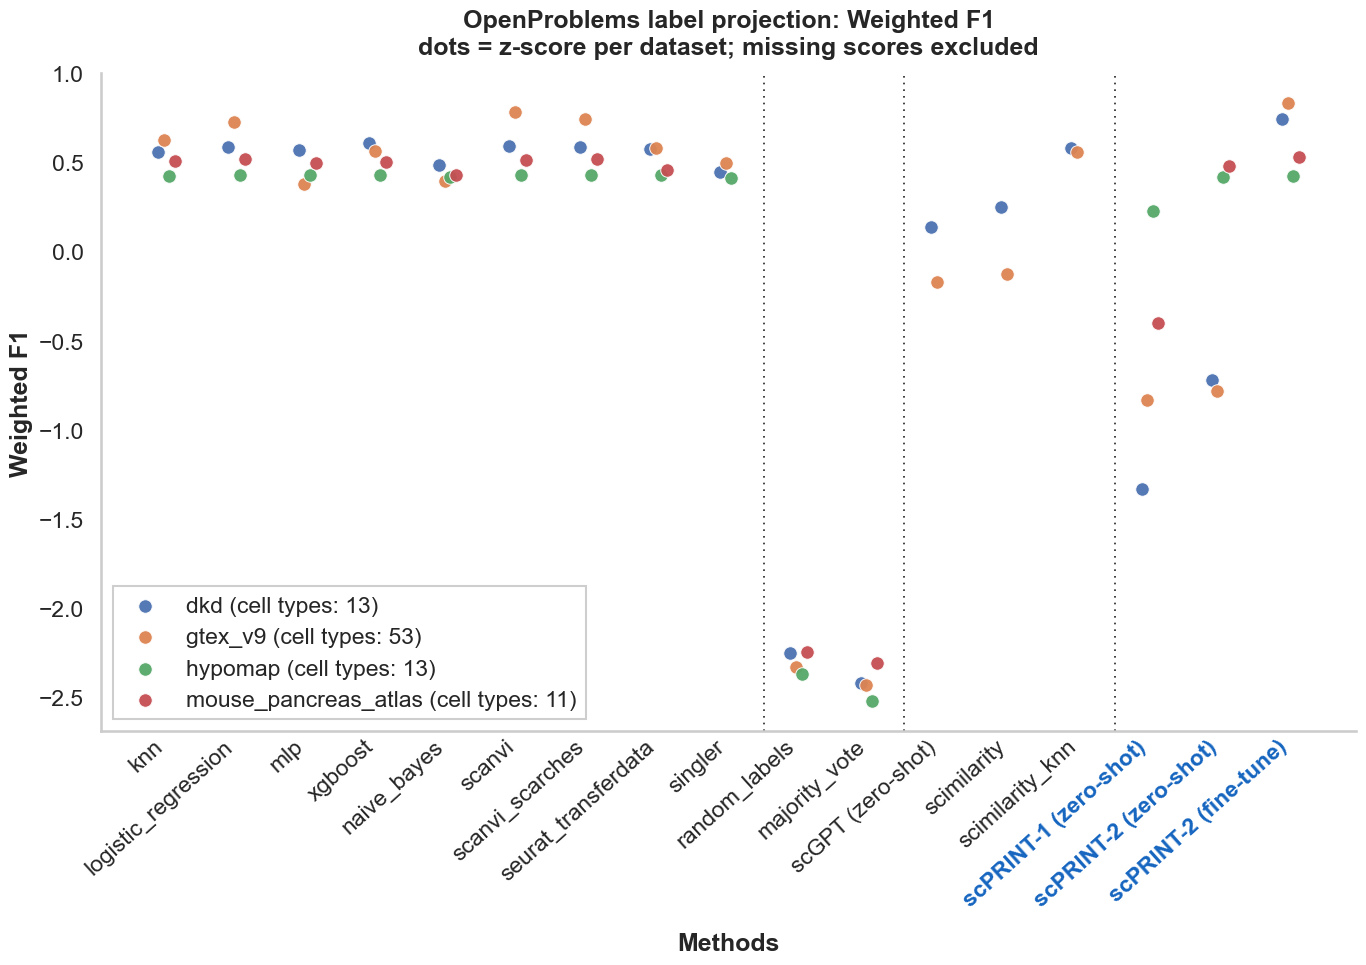

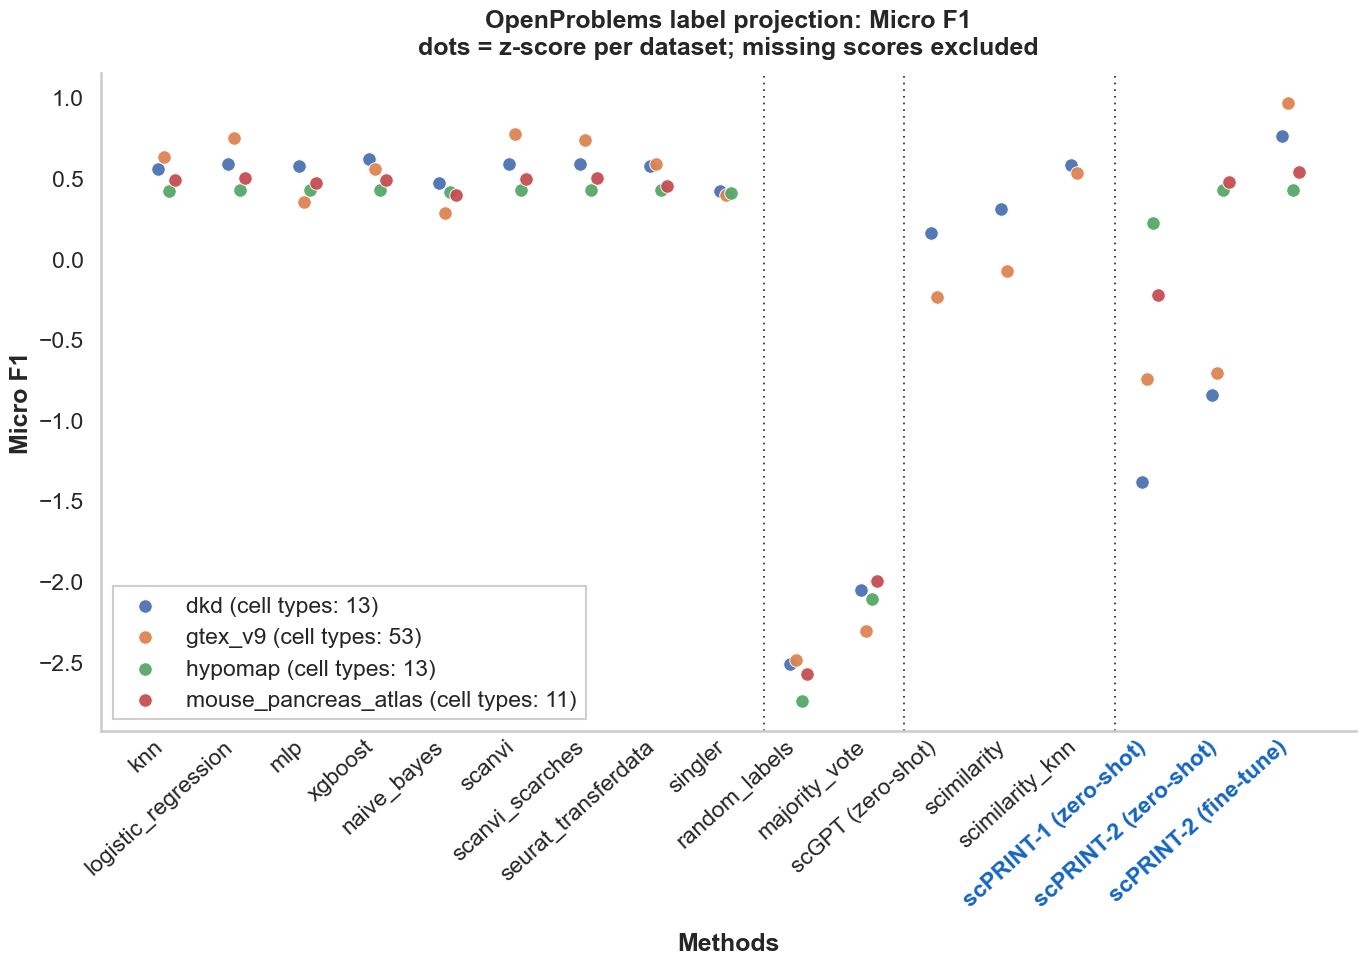

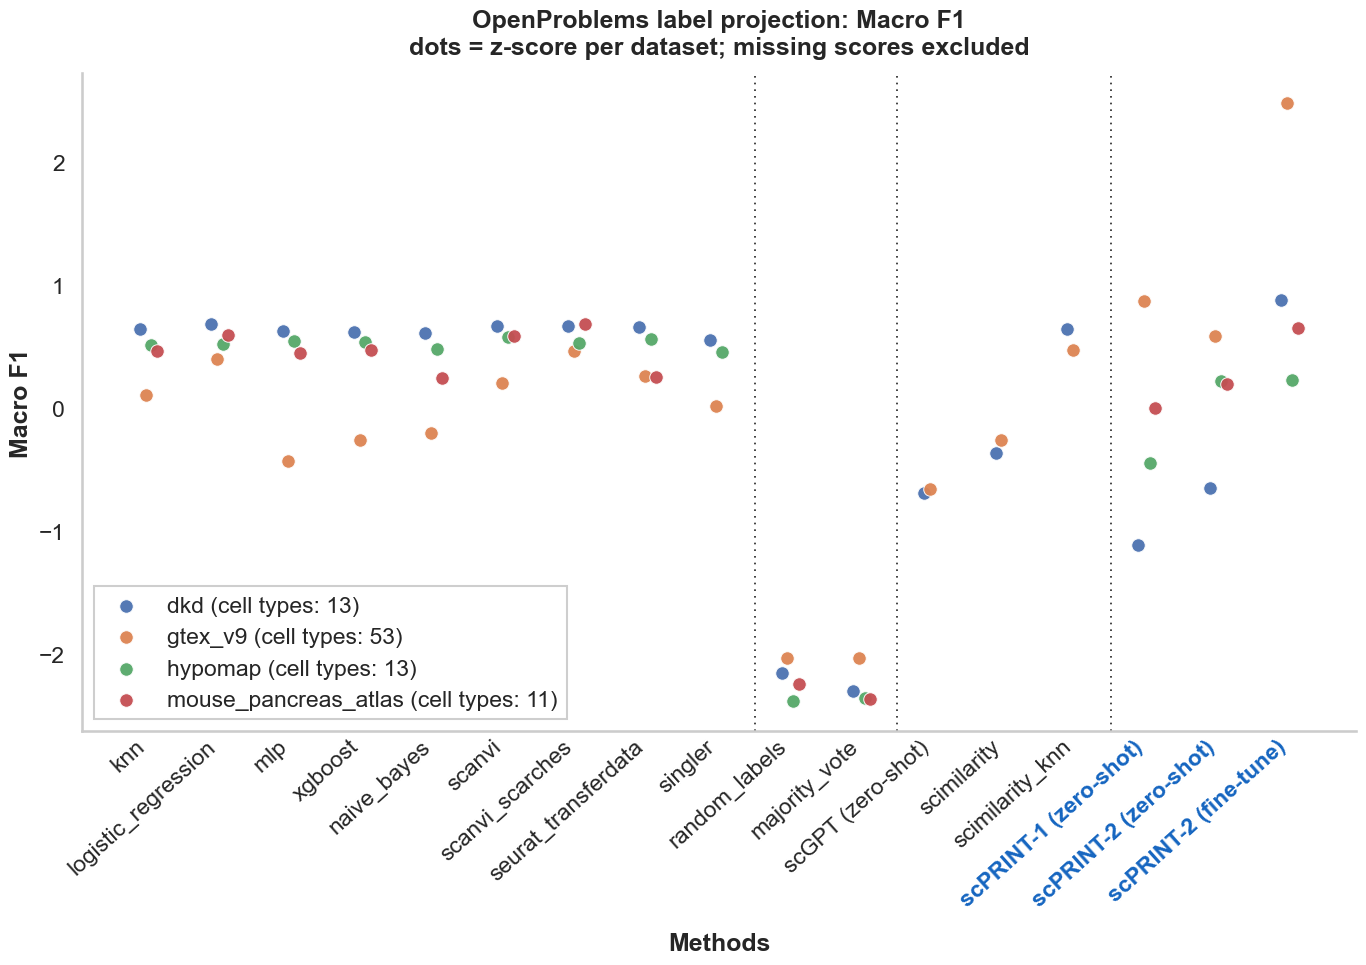

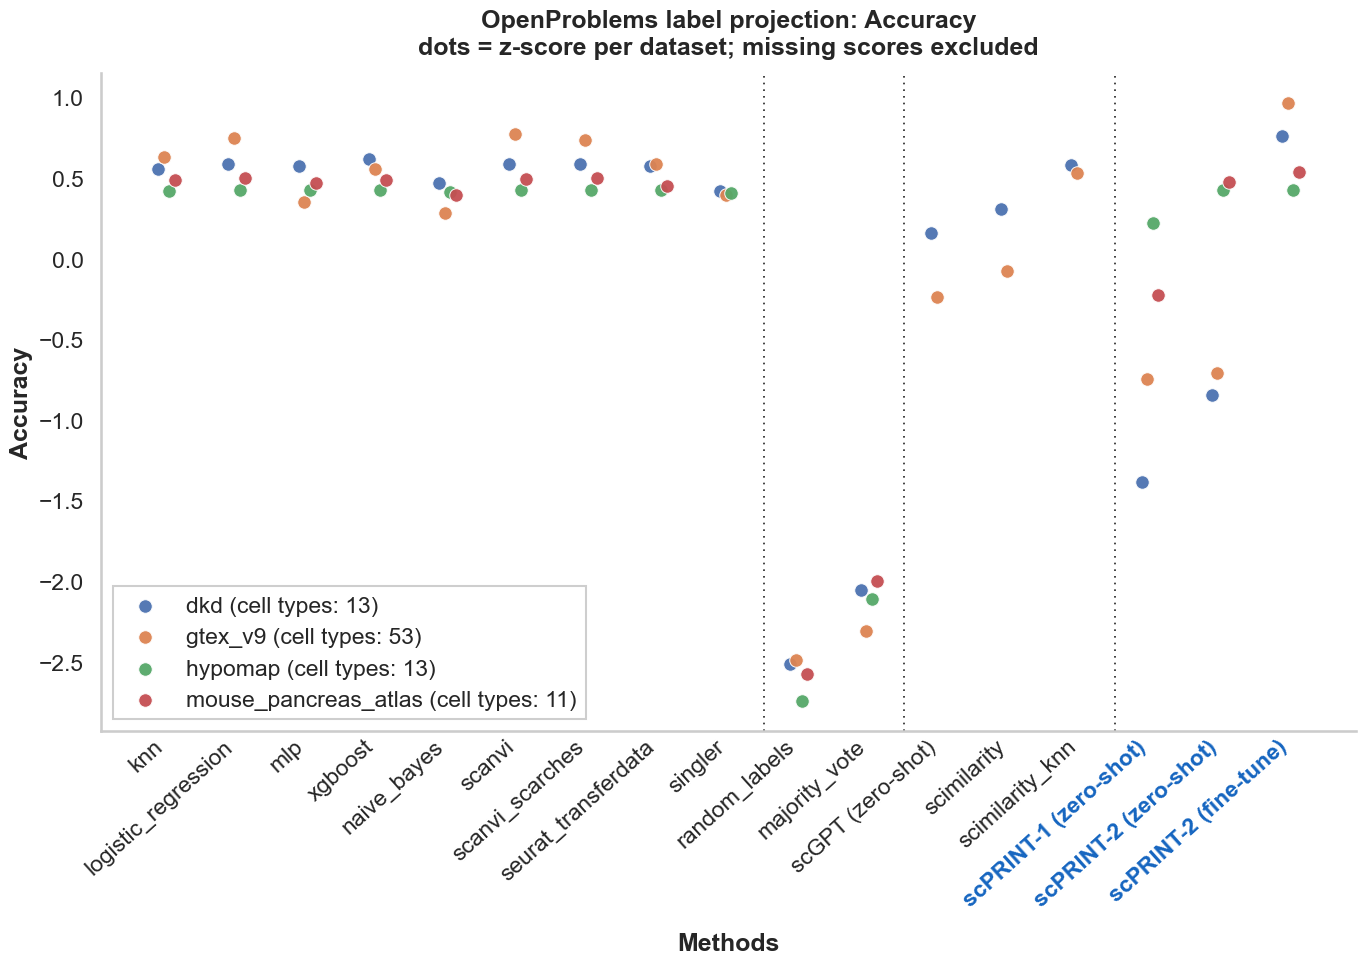

,count,mean,std,median
Method,,,,
knn,4,0.528,0.086,0.532
logistic_regression,4,0.563,0.125,0.551
mlp,4,0.468,0.083,0.462
xgboost,4,0.527,0.078,0.534
naive_bayes,4,0.432,0.039,0.425
scanvi,4,0.580,0.151,0.552
scanvi_scarches,4,0.568,0.134,0.551
seurat_transferdata,4,0.511,0.080,0.518
singler,3,0.453,0.044,0.448


In [10]:
classification_summaries = {}
for metric, (_, display_name) in classification_metric_map.items():
    classification_summaries[metric] = plot_score_distribution(
        classification_score_tables[metric],
        score_name=display_name,
        title=f"OpenProblems label projection: {display_name}",
        filename=f"classification_{metric}",
        dataset_labels=CLASSIFICATION_DATASET_LABELS,
        show_model_separators=True,
    )

classification_summaries["f1_weighted"]

## Batch correction

In [11]:
emb = pd.DataFrame(
    data={
        "Isolated labels": [
            0.621361,
            0.387139,
            0.520031,
            0.544676,
        ],
        "KMeans NMI": [
            0.655657,
            0.570249,
            0.61668,
            0.516657,
        ],
        "KMeans ARI": [
            0.439839,
            0.225424,
            0.280595,
            0.35364,
        ],
        "Silhouette label": [
            0.562681,
            0.61172,
            0.503856,
            0.547946,
        ],
        "cLISI": [
            0.99952,
            1.0,
            0.996694,
            0.992218,
        ],
        "BRAS": [
            0.739654,
            0.786443,
            0.803204,
            0.761943,
        ],
        "iLISI": [
            0.043682,
            0.0,
            0.077398,
            0.19466,
        ],
        "KBET": [
            0.239296,
            0.844529,
            0.353033,
            0.212243,
        ],
        "Graph connectivity": [
            0.854861,
            0.826488,
            0.704139,
            0.857564,
        ],
        "PCR comparison": [
            0,
            0.41701,
            0.096562,
            0.736278,
        ],
        "Batch correction": [
            0.375498,
            0.574894,
            0.406867,
            0.552538,
        ],
        "Bio conservation": [
            0.655811,
            0.558906,
            0.583571,
            0.591027,
        ],
        "Total": [
            0.543686,
            0.565301,
            0.51289,
            0.575631,
        ],
    },
    index=["mouse_pancreas_atlas", "hypomap", "gtex_v9", "dkd"],
)

In [12]:
emb_v1 = pd.DataFrame(
    data={
        "Isolated labels": [
            0.566661,
            0.511032,
            0.509863,
            0.657649,
        ],
        "KMeans NMI": [0.645338, 0.238028, 0.567372, 0.426683],
        "KMeans ARI": [0.31973, 0.11652, 0.391042, 0.134236],
        "Silhouette label": [0.508098, 0.514257, 0.54277, 0.558273],
        "cLISI": [0.997801, 0.956136, 0.999368, 1.0],
        "BRAS": [0.816372, 0.74002, 0.682742, 0.778155],
        "iLISI": [0.052263, 0.150554, 0.03697, 0.0],
        "KBET": [0.314974, 0.169856, 0.193596, 0.849659],
        "Graph connectivity": [0.764403, 0.768737, 0.872287, 0.825514],
        "PCR comparison": [
            0,
            0.269315,
            0,
            0,
        ],
        "Batch correction": [0.389602, 0.419696, 0.357119, 0.490666],
        "Bio conservation": [0.607526, 0.467195, 0.63164, 0.525811],
        "Total": [0.520356, 0.448195, 0.521832, 0.511753],
    },
    index=[
        "gtex_v9",
        "dkd",
        "hypomap",
        "mouse_pancreas_atlas",
    ],
)

In [13]:
emb_ft = pd.DataFrame(
    data={
        "Isolated labels": [0.709752, 0.582134, 0.174419, 0.78184],
        "KMeans NMI": [0.792065, 0.804217, 0.747984, 0.799543],
        "KMeans ARI": [0.664956, 0.523745, 0.438869, 0.633139],
        "Silhouette label": [0.735049, 0.670654, 0.856273, 0.756145],
        "cLISI": [
            1.0,
            0.999889,
            1.0,
            1.0,
        ],
        "BRAS": [0.740067, 0.699155, 0.575672, 0.721834],
        "iLISI": [1.0, 0.037238, 0.0, 0.041376],
        "KBET": [0.264008, 0.335034, 0.83096, 0.274245],
        "Graph connectivity": [0.92774, 0.886459, 0.887689, 0.953396],
        "PCR comparison": [0.798539, 0, 0.533793, 0.177941],
        "Batch correction": [0.58494, 0.391577, 0.565623, 0.433758],
        "Bio conservation": [0.780365, 0.716128, 0.643509, 0.794133],
        "Total": [0.702195, 0.586308, 0.612354, 0.649983],
    },
    index=["dkd", "gtex_v9", "hypomap", "mouse_pancreas_atlas"],
)

In [14]:
bio_metrics = ["ari", "nmi", "isolated_label_asw", "clisi", "asw_label"]
batch_metrics = ["pcr", "graph_connectivity", "asw_batch", "ilisi", "kbet"]
scprint_batch_results = {
    "scPRINT-1 (zero-shot)": emb_v1,
    "scPRINT-2 (zero-shot)": emb,
    "scPRINT-2 (fine-tune)": emb_ft,
}
batch_method_order = [
    "no_integration_batch",
    "no_integration",
    "shuffle_integration",
    "shuffle_integration_by_batch",
    "shuffle_integration_by_cell_type",
    "embed_cell_types",
    "embed_cell_types_jittered",
    "bbknn",
    "scanorama",
    "batchelor_fastmnn",
    "harmony",
    "combat",
    "harmonypy",
    "scalex",
    "scanvi",
    "pyliger",
    "liger",
    "scvi",
    "uce",
    "scgpt_zeroshot",
    "scimilarity",
    "scPRINT-1 (zero-shot)",
    "scPRINT-2 (zero-shot)",
    "scPRINT-2 (fine-tune)",
]


def mean_metric_values(metric_values, metric_names):
    raw_values = [metric_values.get(name, np.nan) for name in metric_names]
    values = pd.to_numeric(
        pd.Series([np.nan if value == "NA" else value for value in raw_values]),
        errors="coerce",
    )
    # Preserve the original scIB aggregation: unavailable constituent metrics
    # are skipped in the numerator, while the denominator remains fixed at five.
    # A model/dataset pair with no reported metric remains genuinely missing.
    if not values.notna().any():
        return np.nan
    return values.sum(skipna=True) / len(metric_names)


batch_scores = {"Total": {}, "Bio conservation": {}, "Batch correction": {}}
for dataset_id, method_results in batch_results.items():
    dataset_name = dataset_id.split("/")[-1]
    for method, values in method_results.items():
        bio_score = mean_metric_values(values, bio_metrics)
        batch_score = mean_metric_values(values, batch_metrics)
        total_score = 0.4 * bio_score + 0.6 * batch_score
        batch_scores["Bio conservation"].setdefault(method, {})[dataset_name] = bio_score
        batch_scores["Batch correction"].setdefault(method, {})[
            dataset_name
        ] = batch_score
        batch_scores["Total"].setdefault(method, {})[dataset_name] = total_score

    for method, results in scprint_batch_results.items():
        for score_name in batch_scores:
            score = (
                results.loc[dataset_name, score_name]
                if dataset_name in results.index
                else np.nan
            )
            batch_scores[score_name].setdefault(method, {})[dataset_name] = score

batch_score_tables = {
    score_name: pd.DataFrame.from_dict(values, orient="index")
    .drop(
        index=["geneformer", "true_labels", "scgpt_finetuned", "scprint"],
        errors="ignore",
    )
    .reindex(batch_method_order)
    for score_name, values in batch_scores.items()
}

batch_score_tables["Total"]

,dkd,gtex_v9,hypomap,mouse_pancreas_atlas
no_integration_batch,0.466364,0.553324,0.526960,0.571184
no_integration,0.490828,0.544744,0.434536,0.575864
shuffle_integration,0.467232,0.438148,0.383136,0.458796
shuffle_integration_by_batch,0.249932,0.298348,0.261732,0.315468
shuffle_integration_by_cell_type,0.723728,0.673736,0.504704,0.642308
embed_cell_types,0.791124,0.762484,0.681564,0.748560
embed_cell_types_jittered,0.789660,0.761776,0.682476,0.748632
bbknn,0.364520,0.334964,0.337716,0.330144
scanorama,0.420488,0.322620,0.293588,0.464788
batchelor_fastmnn,0.626968,0.538368,0.477280,0.560876


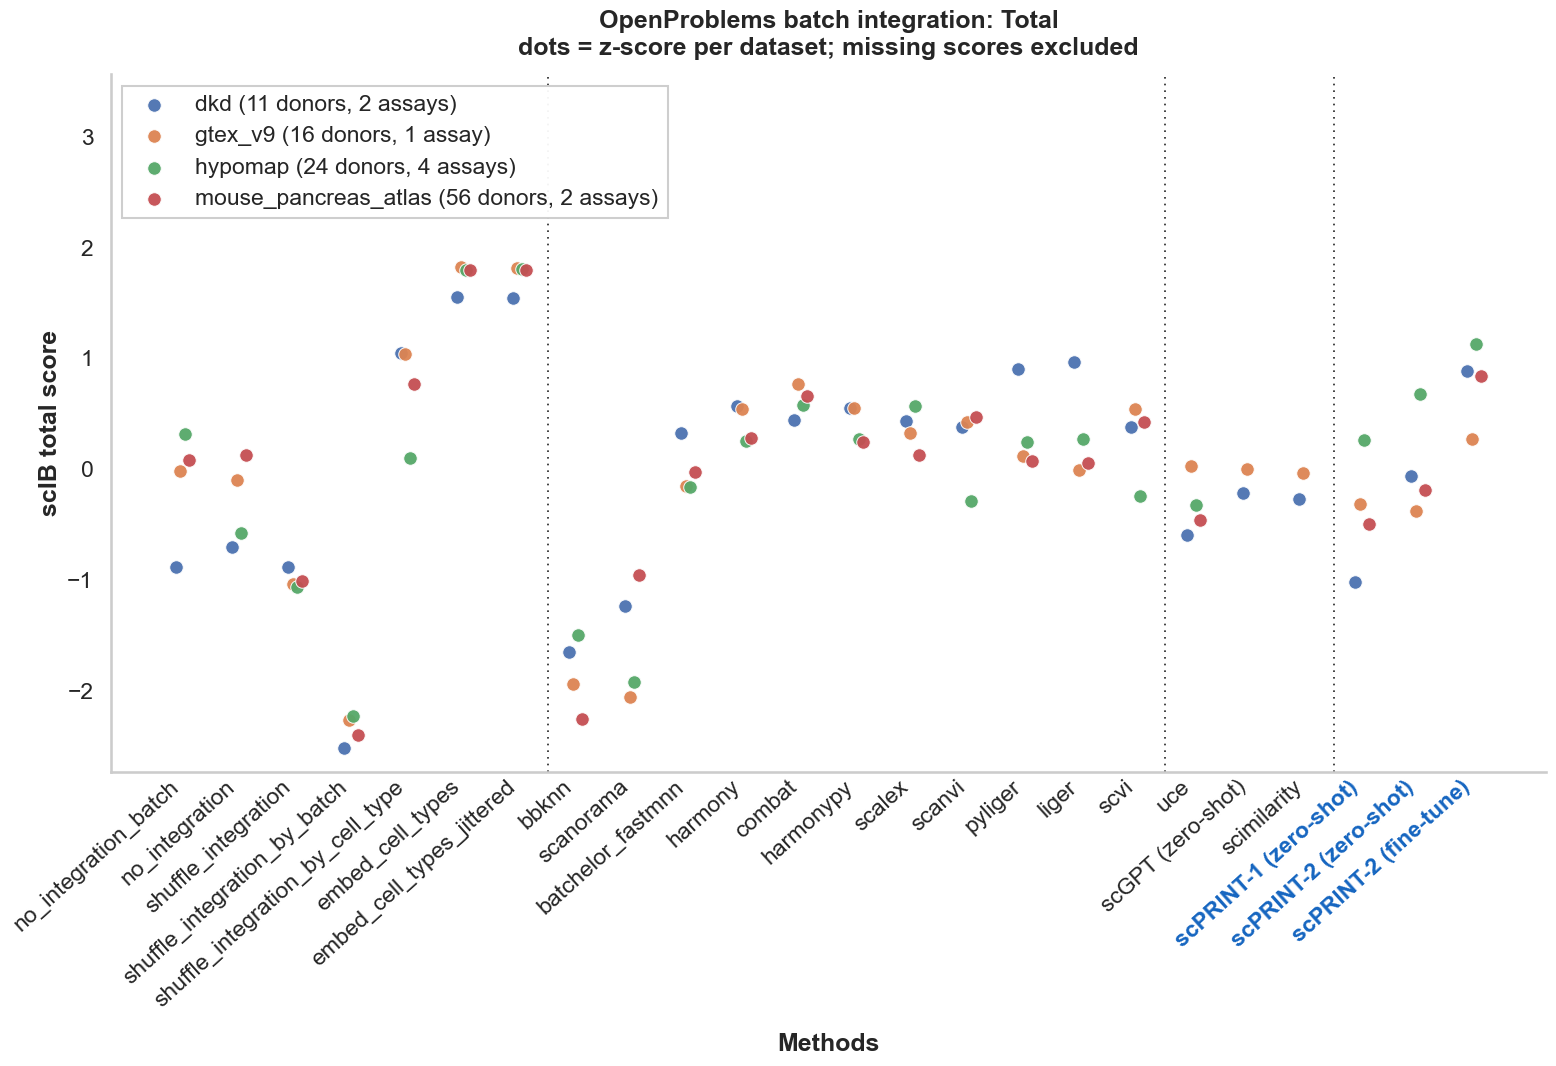

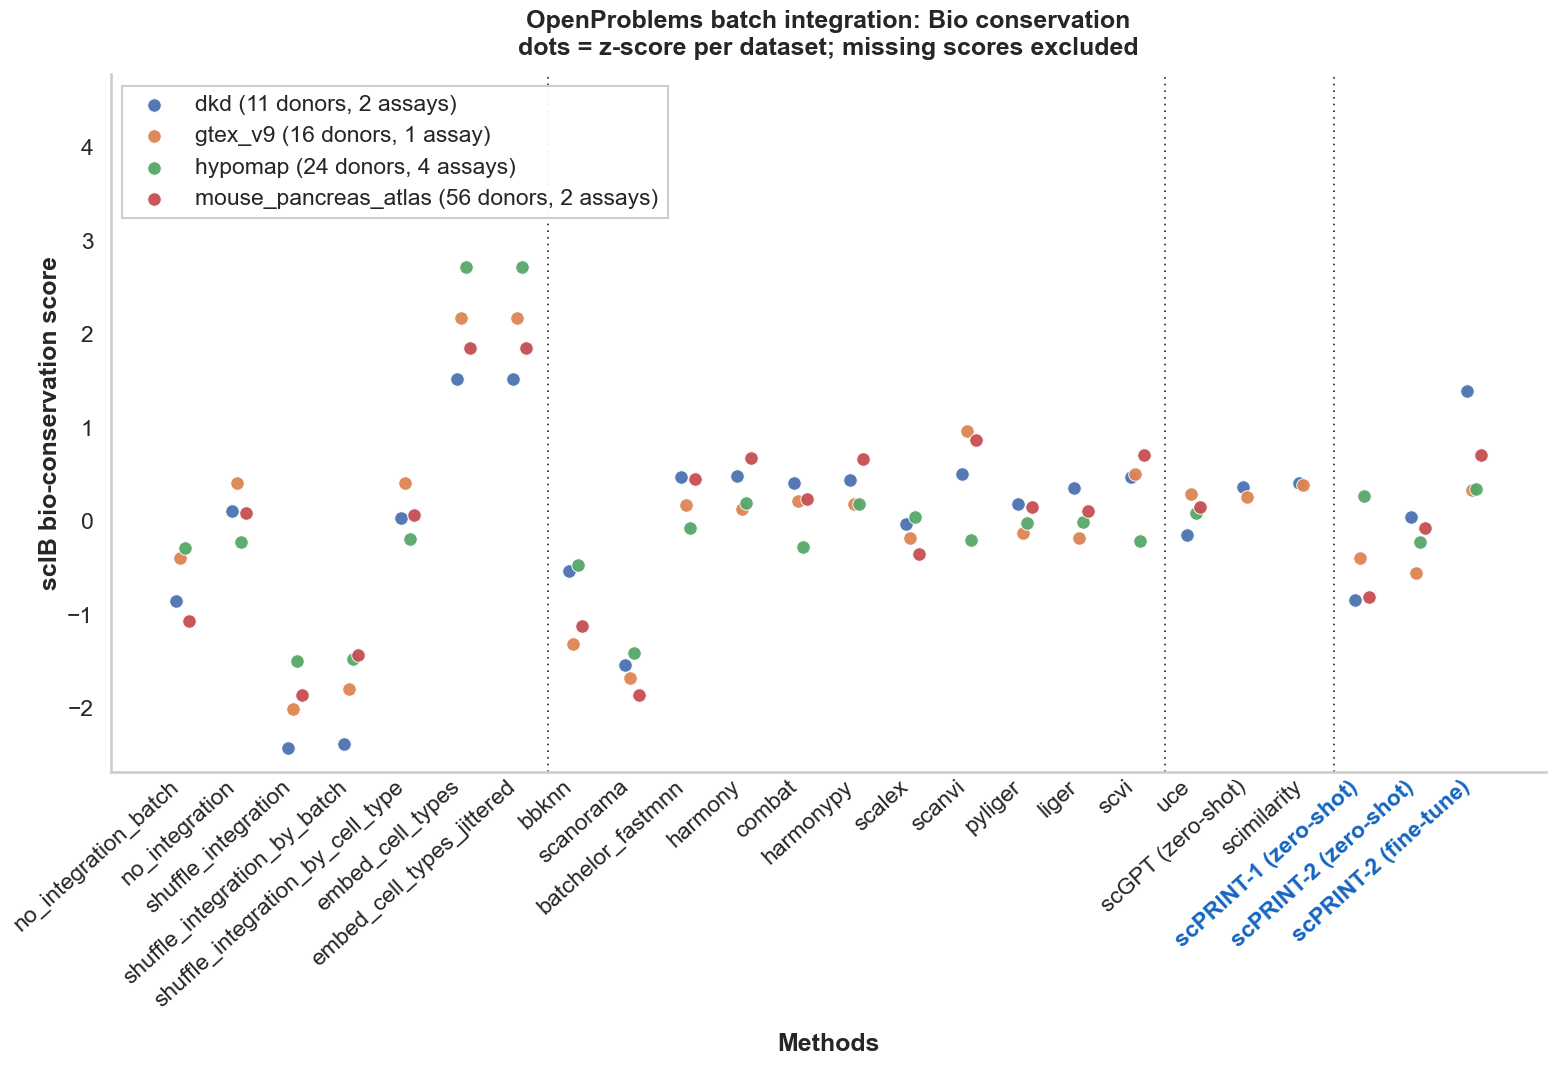

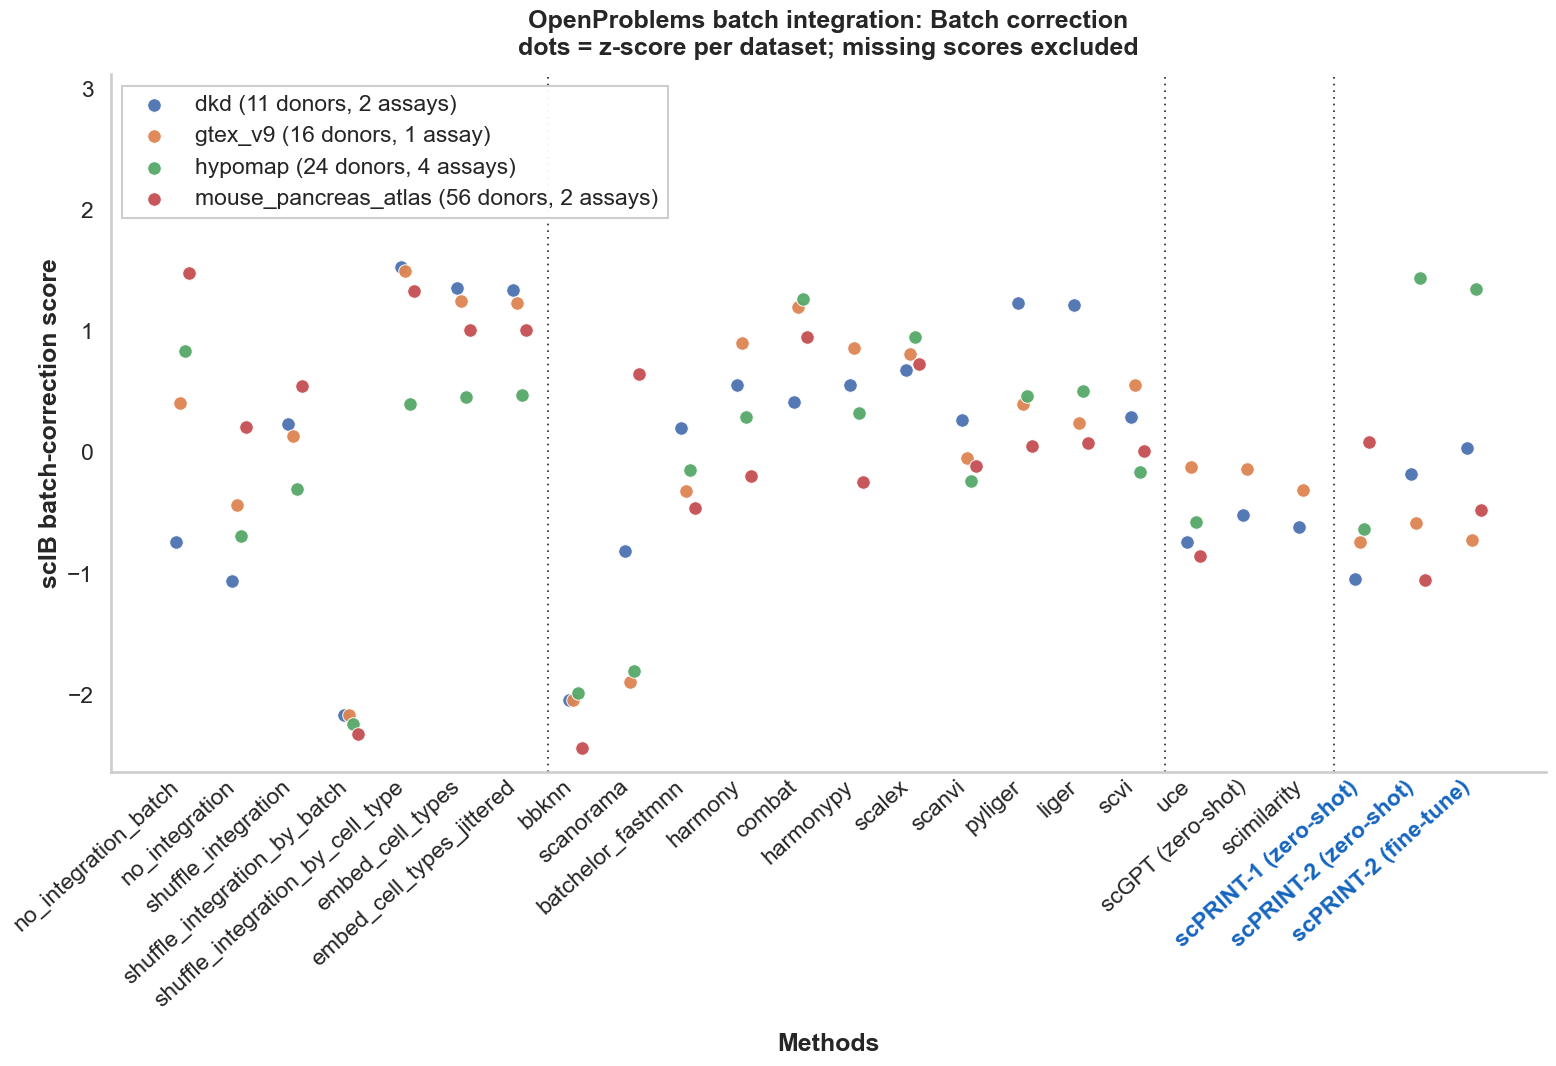

,count,mean,std,median
Method,,,,
no_integration_batch,4,-0.127,0.524,0.031
no_integration,4,-0.310,0.390,-0.332
shuffle_integration,4,-0.995,0.082,-1.020
shuffle_integration_by_batch,4,-2.349,0.130,-2.329
shuffle_integration_by_cell_type,4,0.741,0.446,0.905
embed_cell_types,4,1.744,0.125,1.797
embed_cell_types_jittered,4,1.742,0.130,1.802
bbknn,4,-1.836,0.333,-1.796
scanorama,4,-1.538,0.533,-1.576


In [15]:
batch_plot_specs = {
    "Total": ("scIB total score", "batch_total"),
    "Bio conservation": ("scIB bio-conservation score", "batch_bio_conservation"),
    "Batch correction": ("scIB batch-correction score", "batch_correction"),
}
batch_summaries = {}
for score_name, (axis_label, filename) in batch_plot_specs.items():
    batch_summaries[score_name] = plot_score_distribution(
        batch_score_tables[score_name],
        score_name=axis_label,
        title=f"OpenProblems batch integration: {score_name}",
        filename=filename,
        dataset_labels=BATCH_DATASET_LABELS,
        show_model_separators=True,
        separate_before_methods={
            "bbknn",
            "uce",
            "scPRINT-1 (zero-shot)",
        },
        figure_size=(16, 11),
    )

batch_summaries["Total"]

## Interpretation

With the default settings, every plotted value is a per-dataset z-score and
unavailable model/dataset scores are omitted. The `count` column in each summary
table makes the number of contributing datasets explicit. Set either configuration
flag to `False` and rerun all cells to reproduce the corresponding alternative.